In [6]:
import yfinance as yf

# pandas_datareader 없이 yfinance만 직접 사용
df = yf.download("005930.KS", start="2022-02-21", end="2022-02-22")

# 데이터 확인
df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,005930.KS,005930.KS,005930.KS,005930.KS,005930.KS
Date,,,,,
2022-02-21,67918.265625,67918.265625,67918.265625,67918.265625,0


[*********************100%***********************]  4 of 4 completed



[알림] 종합 분석 그래프가 'comprehensive_analysis.png'로 저장되었습니다.


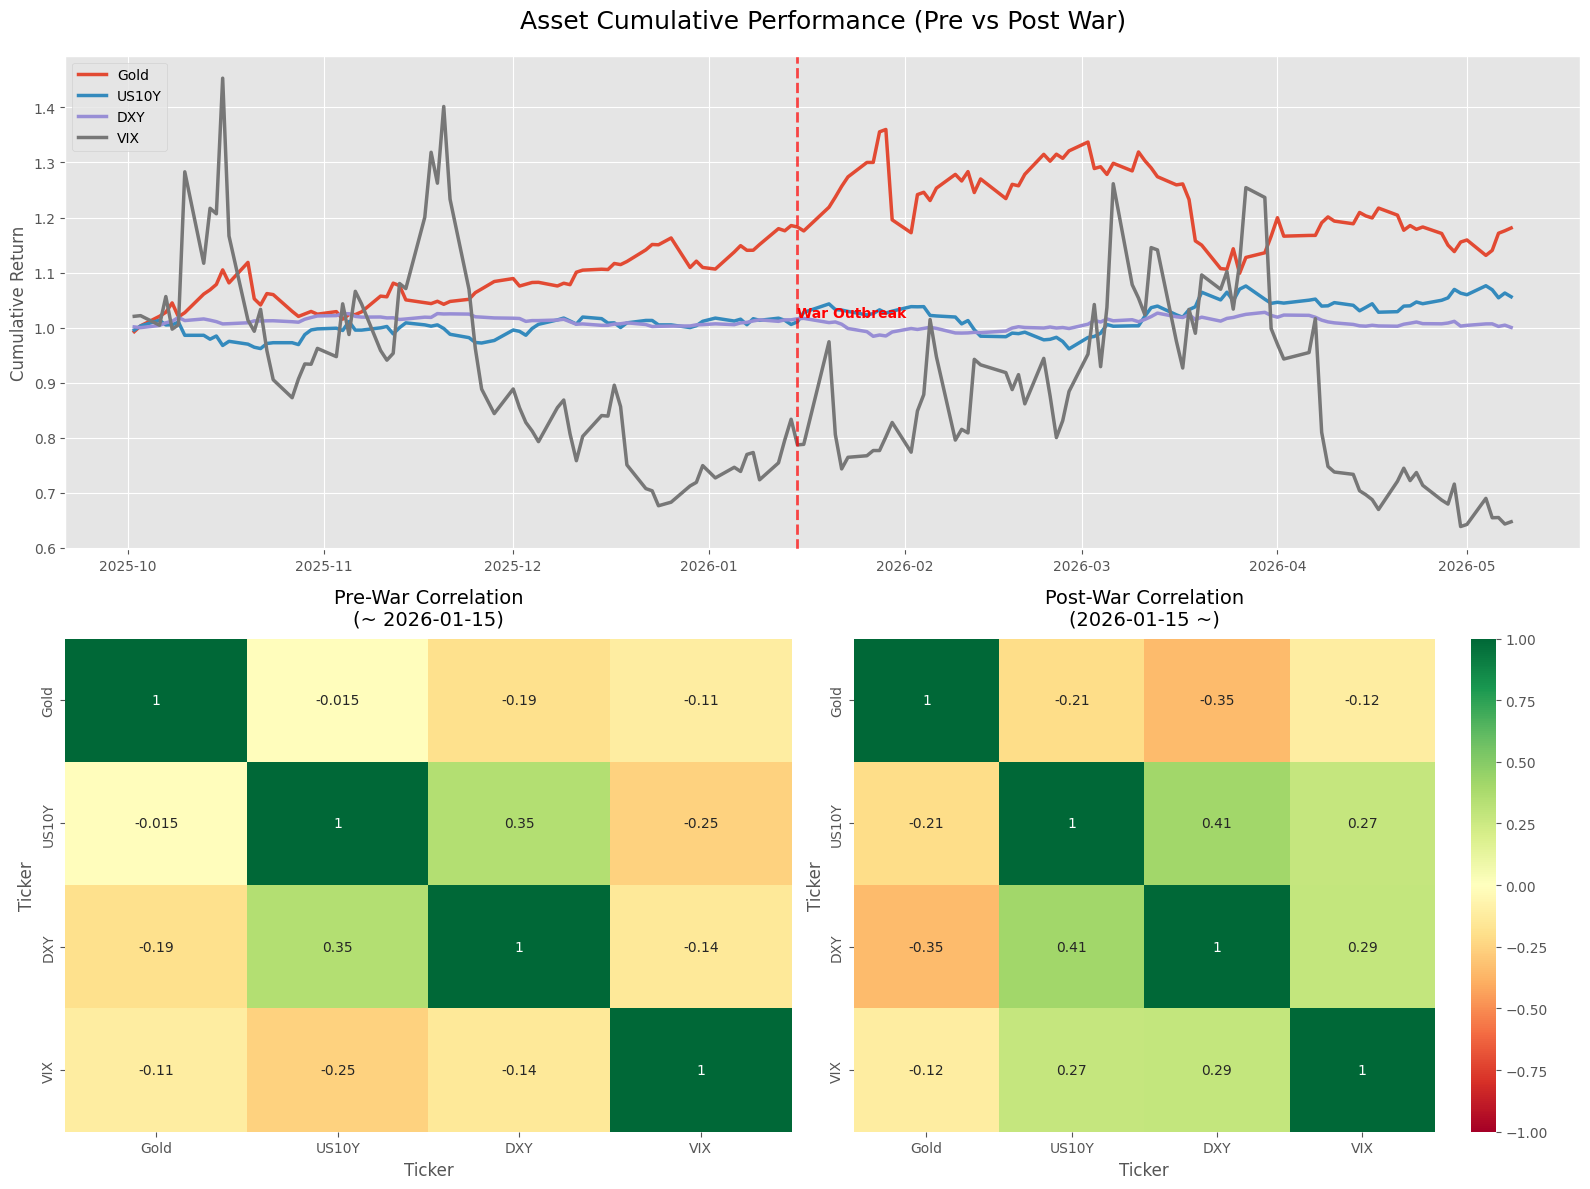


  전쟁 전/후 리스크 지표 비교 (VaR & Volatility)
Asset VaR_Pre(95%) VaR_Post(95%) Risk_Increase Std_Pre Std_Post
 Gold       -2.41%        -3.61%         49.6%   1.56%    2.44%
US10Y       -1.17%        -1.48%         26.4%   0.82%    1.00%
  DXY       -0.46%        -0.78%         71.4%   0.27%    0.41%
  VIX      -12.59%       -14.69%         16.7%   7.72%    8.44%


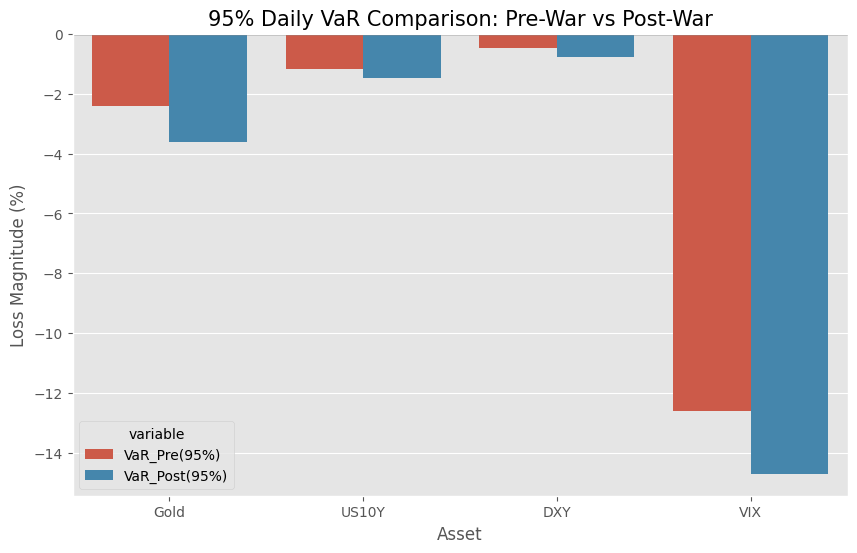

In [ ]:

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# 1. 데이터 설정 (금, 10년물 국채, 달러인덱스, VIX)
tickers = {
    'Gold': 'GC=F', 
    'US10Y': '^TNX', 
    'DXY': 'DX-Y.NYB', 
    'VIX': '^VIX'
}
# 2. 데이터 다운로드 및 구조 정리 (에러 방지 완결판)
start_date = "2025-10-01"
end_date = "2026-05-10"
war_date = "2026-01-15"

# 데이터를 통째로 받은 후
all_data = yf.download(list(tickers.values()), start=start_date, end=end_date)

if all_data.columns.nlevels > 1:
    # 'Adj Close' 컬럼이 존재하는지 확인 후 추출
    if 'Adj Close' in all_data.columns.get_level_values(0):
        raw_data = all_data['Adj Close']
    else:
        raw_data = all_data['Close']
else:
    # 1층 구조인 경우
    raw_data = all_data

# 컬럼명을 원래 tickers의 Key값('Gold', 'US10Y' 등)으로 변경
# yfinance는 다운로드 시 입력한 value 순서대로 컬럼을 정렬하므로 이를 매칭합니다.
ticker_to_name = {v: k for k, v in tickers.items()}
raw_data = raw_data.rename(columns=ticker_to_name)

# 우리가 설정한 이름들만 남기기
raw_data = raw_data[list(tickers.keys())]

# 확인코드
# print("--- 데이터 상단 5행 확인 ---")
# print(raw_data.head())

# print("\n--- 데이터 요약 정보 ---")
# print(raw_data.info())

# print("\n--- 결측치(비어있는 값) 확인 ---")
# print(raw_data.isnull().sum())


# 1. 수익률 계산 및 누적 수익률 생성
returns = np.log(raw_data / raw_data.shift(1)).dropna()
cum_returns = (1 + returns).cumprod()

# 1. 그래프 스타일 및 전체 레이아웃 설정
plt.style.use('ggplot')
# 가로로 긴 히트맵 두 개를 아래에 배치하기 위해 그리드를 조정합니다.
fig = plt.figure(figsize=(16, 12))
gs = fig.add_gridspec(2, 2) # 2행 2열 구조 생성

# [상단] 자산별 누적 수익률 추이 (전체 너비 사용)
ax1 = fig.add_subplot(gs[0, :]) 
for col in cum_returns.columns:
    ax1.plot(cum_returns[col], label=col, linewidth=2.5)

ax1.axvline(pd.to_datetime(war_date), color='red', linestyle='--', alpha=0.7, linewidth=2)
ax1.annotate('War Outbreak', xy=(pd.to_datetime(war_date), 1.02), color='red', fontweight='bold')
ax1.set_title('Asset Cumulative Performance (Pre vs Post War)', fontsize=18, pad=20)
ax1.set_ylabel('Cumulative Return', fontsize=12)
ax1.legend(loc='upper left')

# [하단 왼쪽] 전쟁 전 상관관계 (Pre-War)
ax2 = fig.add_subplot(gs[1, 0])
pre_war_corr = returns.loc[:war_date].corr()
sns.heatmap(pre_war_corr, annot=True, cmap='RdYlGn', ax=ax2, center=0, vmin=-1, vmax=1, cbar=False)
ax2.set_title(f'Pre-War Correlation\n(~ {war_date})', fontsize=14, pad=10)

# [하단 오른쪽] 전쟁 후 상관관계 (Post-War)
ax3 = fig.add_subplot(gs[1, 1])
post_war_corr = returns.loc[war_date:].corr()
sns.heatmap(post_war_corr, annot=True, cmap='RdYlGn', ax=ax3, center=0, vmin=-1, vmax=1)
ax3.set_title(f'Post-War Correlation\n({war_date} ~)', fontsize=14, pad=10)

plt.tight_layout()

# 결과 저장 및 출력
plt.savefig('comprehensive_analysis.png', dpi=300) # 고해상도 저장
print("\n[알림] 종합 분석 그래프가 'comprehensive_analysis.png'로 저장되었습니다.")
plt.show()

# 1. VaR (Value at Risk) 계산 함수 정의
def calculate_var(returns_series, confidence_level=0.95):
    # 하위 5%에 해당하는 수익률 지점을 찾음 (95% 신뢰수준)
    return np.percentile(returns_series, (1 - confidence_level) * 100)

# 2. 전쟁 전/후 각 자산별 VaR 계산
assets = returns.columns
var_results = []

for asset in assets:
    var_pre = calculate_var(pre_war[asset])
    var_post = calculate_var(post_war[asset])
    
    # 변동성(표준편차)도 함께 비교
    std_pre = pre_war[asset].std()
    std_post = post_war[asset].std()
    
    var_results.append({
        'Asset': asset,
        'VaR_Pre(95%)': f"{var_pre*100:.2f}%",
        'VaR_Post(95%)': f"{var_post*100:.2f}%",
        'Risk_Increase': f"{(var_post/var_pre - 1)*100:.1f}%" if var_pre != 0 else "N/A",
        'Std_Pre': f"{std_pre*100:.2f}%",
        'Std_Post': f"{std_post*100:.2f}%"
    })

# 3. 결과 출력 및 표 구성
var_df = pd.DataFrame(var_results)
print("\n" + "="*50)
print("  전쟁 전/후 리스크 지표 비교 (VaR & Volatility)")
print("="*50)
print(var_df.to_string(index=False))

# 4. 시각화: VaR 변화 비교 차트
var_plot_data = var_df.melt(id_vars='Asset', value_vars=['VaR_Pre(95%)', 'VaR_Post(95%)'])
var_plot_data['value'] = var_plot_data['value'].str.replace('%', '').astype(float)

plt.figure(figsize=(10, 6))
sns.barplot(data=var_plot_data, x='Asset', y='value', hue='variable')
plt.title('95% Daily VaR Comparison: Pre-War vs Post-War', fontsize=15)
plt.ylabel('Loss Magnitude (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.savefig('var_analysis.png')
plt.show()

[*********************100%***********************]  4 of 4 completed



 [러-우 전쟁] 전후 리스크 지표 비교 (기준일: 2022-02-24)
Asset VaR_Pre VaR_Post Risk_Inc Std_Pre Std_Post
 Gold  -1.65%   -1.66%    1.06%   0.86%    0.96%
US10Y  -4.57%   -3.81%  -16.59%   3.07%    3.03%
  DXY  -0.50%   -0.79%   56.98%   0.34%    0.54%
  VIX -12.09%   -9.50%  -21.40%   9.17%    7.15%


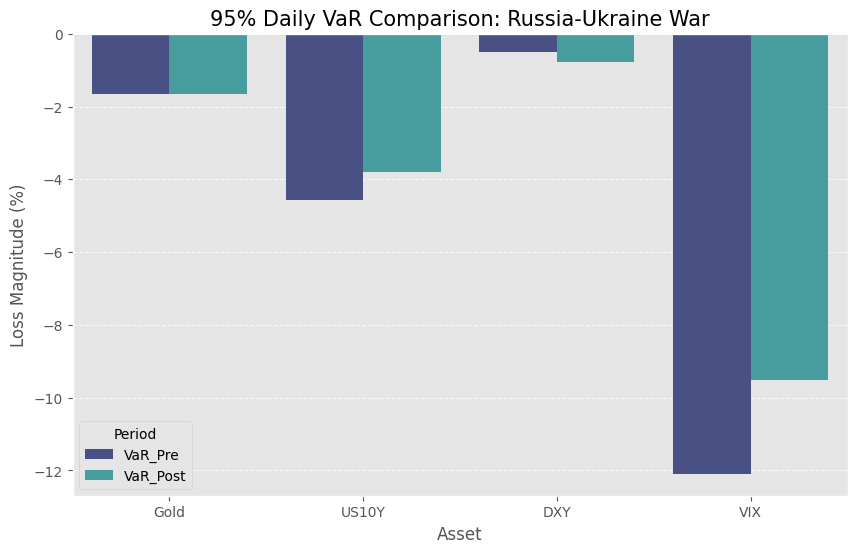

In [16]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 설정 및 다운로드
tickers = {'Gold': 'GC=F', 'US10Y': '^TNX', 'DXY': 'DX-Y.NYB', 'VIX': '^VIX'}
start_date, end_date, war_date = "2021-09-01", "2022-09-01", "2022-02-24"

all_data = yf.download(list(tickers.values()), start=start_date, end=end_date)
raw_data = all_data['Adj Close'] if 'Adj Close' in all_data.columns.get_level_values(0) else all_data['Close']
raw_data = raw_data.rename(columns={v: k for k, v in tickers.items()})[list(tickers.keys())]

# 2. 수익률 및 데이터 분할 (핵심 수정 부분)
returns = np.log(raw_data / raw_data.shift(1)).dropna()
pre_war = returns.loc[:pd.to_datetime(war_date) - pd.Timedelta(days=1)]
post_war = returns.loc[war_date:]

# 3. VaR 계산 함수
def calculate_var(series, confidence=0.95):
    return np.percentile(series, (1 - confidence) * 100)

# 4. 리스크 지표 통합 계산
var_results = []
for asset in returns.columns:
    v_pre, v_post = calculate_var(pre_war[asset]), calculate_var(post_war[asset])
    s_pre, s_post = pre_war[asset].std(), post_war[asset].std()
    
    var_results.append({
        'Asset': asset,
        'VaR_Pre': v_pre * 100,      # 숫자로 저장 (그래프용)
        'VaR_Post': v_post * 100,    # 숫자로 저장 (그래프용)
        'Risk_Inc': (v_post / v_pre - 1) * 100 if v_pre != 0 else 0,
        'Std_Pre': s_pre * 100,
        'Std_Post': s_post * 100
    })

var_df = pd.DataFrame(var_results)

# 5. 결과 출력 (표 제공)
print("\n" + "="*65)
print(f" [러-우 전쟁] 전후 리스크 지표 비교 (기준일: {war_date})")
print("="*65)
display_df = var_df.copy()
for col in ['VaR_Pre', 'VaR_Post', 'Risk_Inc', 'Std_Pre', 'Std_Post']:
    display_df[col] = display_df[col].map("{:.2f}%".format)
print(display_df.to_string(index=False))

# 6. 시각화 (그래프 수정)
plt.figure(figsize=(10, 6))
var_plot_data = var_df.melt(id_vars='Asset', value_vars=['VaR_Pre', 'VaR_Post'], 
                            var_name='Period', value_name='Loss_Pct')

sns.barplot(data=var_plot_data, x='Asset', y='Loss_Pct', hue='Period', palette='mako')
plt.title(f'95% Daily VaR Comparison: Russia-Ukraine War', fontsize=15)
plt.ylabel('Loss Magnitude (%)', fontsize=12)
plt.axhline(0, color='black', linewidth=0.8)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('var_analysis_fixed.png', dpi=300)
plt.show()

In [3]:
import yfinance as yf
import pandas as pd
import numpy as np
import statsmodels.api as sm

# 1. 공통 설정
tickers = {
    'Gold': 'GC=F', 
    'US10Y': '^TNX', 
    'VIX': '^VIX'
}

# 2. 데이터 수집 및 가공 함수 정의
def get_event_data(start, end, war_dt, event_name):
    # 데이터 다운로드 (수정종가 자동 반영)
    raw_data = yf.download(list(tickers.values()), start=start, end=end, auto_adjust=True)
    
    # MultiIndex 대응: 'Close' 컬럼 추출
    if isinstance(raw_data.columns, pd.MultiIndex):
        data = raw_data['Close']
    else:
        data = raw_data
        
    # 컬럼명 변경
    data = data.rename(columns={v: k for k, v in tickers.items()})
    
    # 수익률 및 변화량 계산
    returns = np.log(data / data.shift(1)).dropna()
    
    # 분석용 데이터프레임 구성
    df_event = pd.DataFrame(index=returns.index)
    df_event['Gold_Ret'] = returns['Gold']
    df_event['VIX_diff'] = data['VIX'].diff().reindex(returns.index)
    df_event['Rate_diff'] = data['US10Y'].diff().reindex(returns.index)
    
    # 전쟁 더미 (발발일 이후 1, 이전 0)
    df_event['War_Dummy'] = (df_event.index >= pd.to_datetime(war_dt)).astype(int)
    
    # 교차항 (VIX 변화 * 전쟁 더미): 안전자산 작동 여부 검증 핵심
    df_event['Interaction'] = df_event['VIX_diff'] * df_event['War_Dummy']
    
    # 이벤트 구분 태그
    df_event['Event'] = event_name
    
    return df_event

# 3. 실제 데이터 생성 및 통합 (df_total 정의)
print("--- 데이터 수집 및 통합 시작 ---")

# Case A: 러시아-우크라이나 (대조군: 안전자산 정상 작동)
df_russia = get_event_data("2021-09-01", "2022-09-01", "2022-02-24", "Russia-Ukraine")

# Case B: 미국-중동 (실험군: 안전자산 역할 붕괴 증명)
df_middle_east = get_event_data("2025-10-01", "2026-05-10", "2026-01-15", "US-MiddleEast")

# 데이터 수직 통합
df_total = pd.concat([df_russia, df_middle_east])

print("--- df_total 생성 및 통합 완료 ---")

# 4. 분석 결과 파일 저장 (CSV)
df_total.to_csv("war_analysis_total_data.csv", encoding='utf-8-sig')
df_total[df_total['Event'] == "Russia-Ukraine"].to_csv("data_russia_ukraine.csv", encoding='utf-8-sig')
df_total[df_total['Event'] == "US-MiddleEast"].to_csv("data_us_middle_east.csv", encoding='utf-8-sig')

print("\n[알림] 데이터 CSV 저장 완료.")

# 5. 회귀분석 실행 및 결과 텍스트 파일 저장
with open("regression_summary.txt", "w", encoding='utf-8') as f:
    for event in ["Russia-Ukraine", "US-MiddleEast"]:
        subset = df_total[df_total['Event'] == event].dropna()
        
        # 독립변수: 상수항, VIX변화량, 전쟁더미, 금리변화량, 교차항
        X = subset[['VIX_diff', 'War_Dummy', 'Rate_diff', 'Interaction']]
        X = sm.add_constant(X)
        
        model = sm.OLS(subset['Gold_Ret'], X).fit()
        
        # 화면 출력
        print(f"\n=== {event} 회귀 분석 결과 ===")
        print(model.summary().tables[1])
        
        # 파일 작성
        f.write(f"\n{'='*30} {event} 분석 결과 {'='*30}\n")
        f.write(model.summary().as_text())
        f.write("\n\n")

print("\n[알림] 회귀분석 요약 결과가 'regression_summary.txt'로 저장되었습니다.")

[*********************100%***********************]  3 of 3 completed

--- 데이터 수집 및 통합 시작 ---



[*********************100%***********************]  3 of 3 completed

--- df_total 생성 및 통합 완료 ---

[알림] 데이터 CSV 저장 완료.

=== Russia-Ukraine 회귀 분석 결과 ===
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0007      0.001      0.812      0.417      -0.001       0.002
VIX_diff    -1.673e-05      0.000     -0.043      0.966      -0.001       0.001
War_Dummy      -0.0011      0.001     -1.004      0.316      -0.003       0.001
Rate_diff      -0.0395      0.009     -4.616      0.000      -0.056      -0.023
Interaction     0.0005      0.001      0.837      0.403      -0.001       0.002

=== US-MiddleEast 회귀 분석 결과 ===
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0025      0.002      1.044      0.298      -0.002       0.007
VIX_diff       -0.0013      0.002     -0.821      0.413      -0.004       0.002
War_Du